In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

emendas = pd.read_csv('EmendasParlamentares.csv', encoding='latin1', sep=';')

C:\Users\logeg\AppData\Local\Temp\ipykernel_5836\625364067.py:6: DtypeWarning: Columns (0,3,5) have mixed types. Specify dtype option on import or set low_memory=False.
  emendas = pd.read_csv('EmendasParlamentares.csv', encoding='latin1', sep=';')


In [13]:
# excluindo colunas que não serão úteis:
emendas = emendas.drop(["Código da Emenda", "Tipo de Emenda", "Código Município IBGE", "Município", "Nome do Autor da Emenda", "Código do Autor da Emenda", "Número da emenda", "Código Ação", "Código Plano Orçamentário", "Valor Liquidado", "Valor Restos A Pagar Inscritos"], axis=1)
# colunas "Código da Emenda", "Código Município IBGE" e "Município" possuiam muitos campos "Sem informação", foram excluídos porque não serão utilizados

In [14]:
#limpando campos Sem informação
emendas = emendas.replace("Sem informação", np.nan) # substitui os celulas com valor "Sem informação" por vazio
emendas = emendas.dropna() # Exclui toda a linha caso tenha pelo menos um valor vazio


In [15]:
# Substituindo valores "Múltiplos" por "Interestadual" da coluna UF
emendas['UF'] = emendas['UF'].replace("Múltiplo", "Interestadual")

In [16]:
# transformando colunas de texto em numero:
colunas_a_transformar = ["Valor Empenhado", "Valor Pago", "Valor Restos A Pagar Cancelados", "Valor Restos A Pagar Pagos"]

def tranformar_em_int(colunas):
    for coluna in colunas:
        emendas[coluna] = emendas[coluna].astype(str).str.replace(',', '.', regex=False).astype(float)    

tranformar_em_int(colunas_a_transformar)

In [17]:
# definindo o campo Ano da Emenda como string para evitar que o codigo realize operaçoes com ele, prejudicando os graficos
emendas["Ano da Emenda"] = emendas["Ano da Emenda"].astype(str)

In [ ]:
# criando medidas:
def calcular_medidas():
    global total_por_uf_bi, total_por_funcao_bi, total_pago_por_ano_bi, gap_empenhado_e_pago

    total_por_uf = emendas.groupby(emendas["UF"]).sum(numeric_only=True).round(2)
    total_por_uf_bi = total_por_uf / 1000000000 # total gasto por bilhao

    total_por_funcao = emendas.groupby(emendas["Nome Função"]).sum(numeric_only=True).round(2)
    total_por_funcao_bi = total_por_funcao / 1000000000 # total gasto por bilhao

    total_por_ano = emendas.groupby(emendas["Ano da Emenda"]).sum(numeric_only=True).round(2)
    total_por_ano_bi = total_por_ano / 1000000000 # total gasto por bilhao
    total_por_ano_bi = total_por_ano_bi.reset_index() # transformando o index em uma coluna

    gap_empenhado_e_pago = total_por_uf_bi[["Valor Empenhado", "Valor Pago"]]

calcular_medidas()

display(total_pago_por_ano_bi)

,Ano da Emenda,Código UF IBGE,Valor Empenhado,Valor Pago,Valor Restos A Pagar Cancelados,Valor Restos A Pagar Pagos
0,2014,36.607600,6.027787,0.130748,1.382643,4.455653
1,2015,11.455200,3.345301,0.019761,0.561346,2.714569
2,2016,24.115200,14.415117,5.473875,1.537804,6.999404
3,2017,28.711400,13.997970,3.226283,1.637062,8.623337
4,2018,21.323099,11.848066,5.400222,1.053289,5.172871
5,2019,25.294600,13.221160,5.724926,0.861522,6.071346
6,2020,23.960298,31.948449,14.381311,2.974779,13.287428
7,2021,19.142199,32.748837,15.508571,1.872867,12.623163
8,2022,17.436499,25.065023,16.875025,0.531318,6.468486
9,2023,17.042398,34.407112,21.649794,0.678101,7.002964


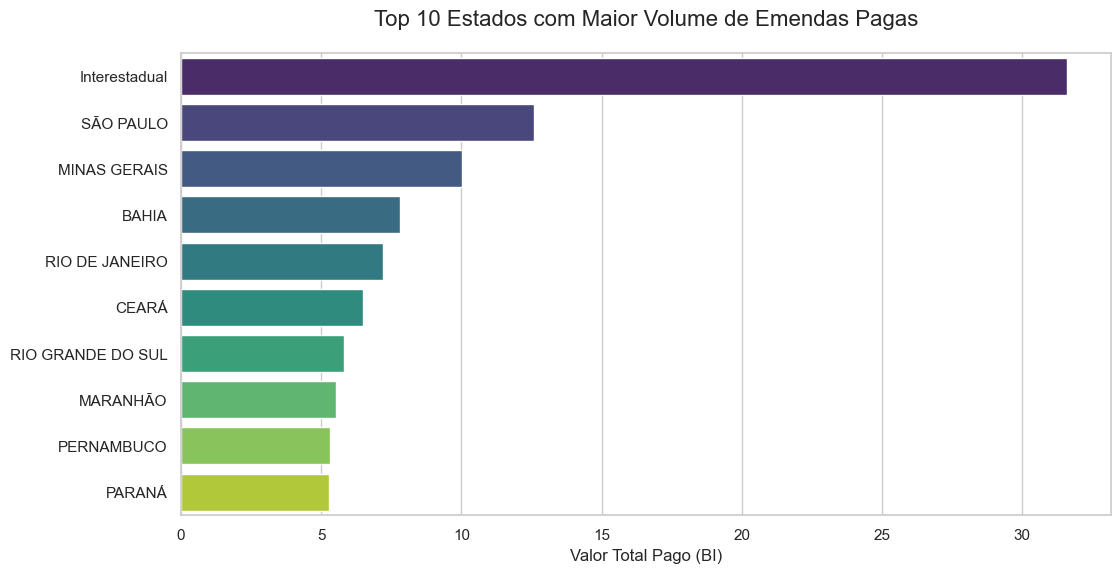

In [66]:
# ordenando e limitando a 10 primeiras linhas
top_10_uf = total_por_uf_bi.sort_values(by='Valor Pago', ascending=False).head(10)

# visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

grafico = sns.barplot(
    data=top_10_uf, 
    x='Valor Pago', 
    y='UF', 
    hue='UF',  
    palette='viridis',
    legend=False
)

plt.title('Top 10 Estados com Maior Volume de Emendas Pagas', fontsize=16, pad=20) #titulo
plt.xlabel('Valor Total Pago (BI)', fontsize=12) 
plt.ylabel('')

plt.show()
plt.close()

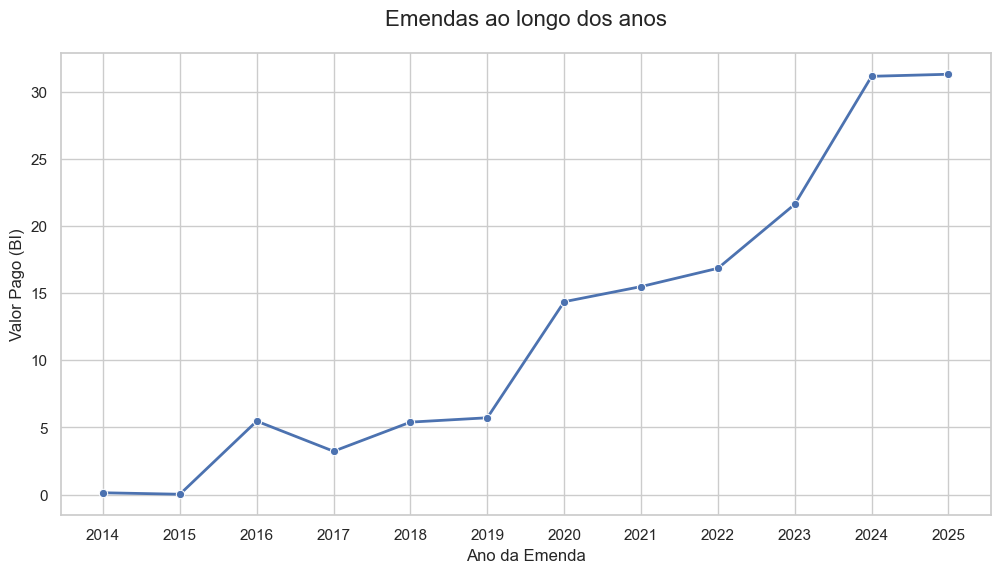

In [ ]:
# excluindo o ano 2026 p/ não prejudicar o gráfico (ano vigente)
total_pago_por_ano_bi = total_pago_por_ano_bi.loc[total_pago_por_ano_bi["Ano da Emenda"] != "2026"]

# definindo visual
sns.set_theme(style="whitegrid") 
plt.figure(figsize=(12, 6))

grafico = sns.lineplot(
    data=total_pago_por_ano_bi, 
    x='Ano da Emenda', 
    y='Valor Pago', 
    marker='o', 
    linewidth=2
)

plt.title('Emendas ao longo dos anos', fontsize=16, pad=20)
plt.xlabel('Ano da Emenda', fontsize=12)
plt.ylabel('Valor Pago (BI)', fontsize=12)

plt.show()
plt.close()

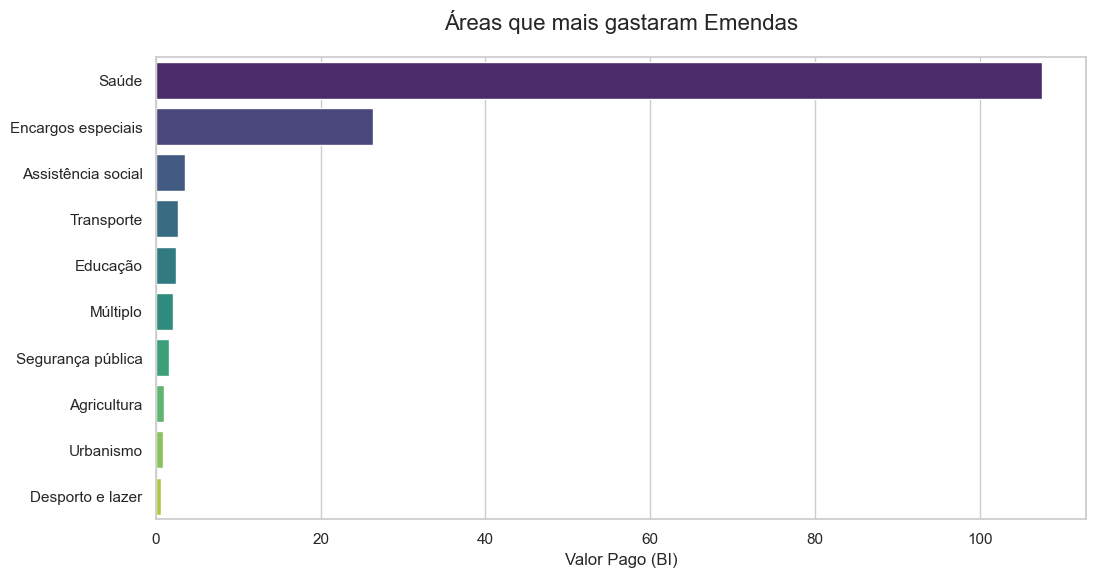

In [67]:
# ordenando e coletando somente os top 10
top_10_funcao = total_por_funcao_bi.sort_values(by='Valor Pago', ascending=False).head(10)

# definindo visual
sns.set_theme(style="whitegrid") 
plt.figure(figsize=(12, 6))

grafico = sns.barplot(
    data=top_10_funcao, 
    x='Valor Pago', 
    y='Nome Função', 
    hue="Nome Função",
    palette='viridis',
    legend=False
)

plt.title('Áreas que mais gastaram Emendas', fontsize=16, pad=20)
plt.xlabel('Valor Pago (BI)', fontsize=12)
plt.ylabel('')

plt.show()
plt.close()

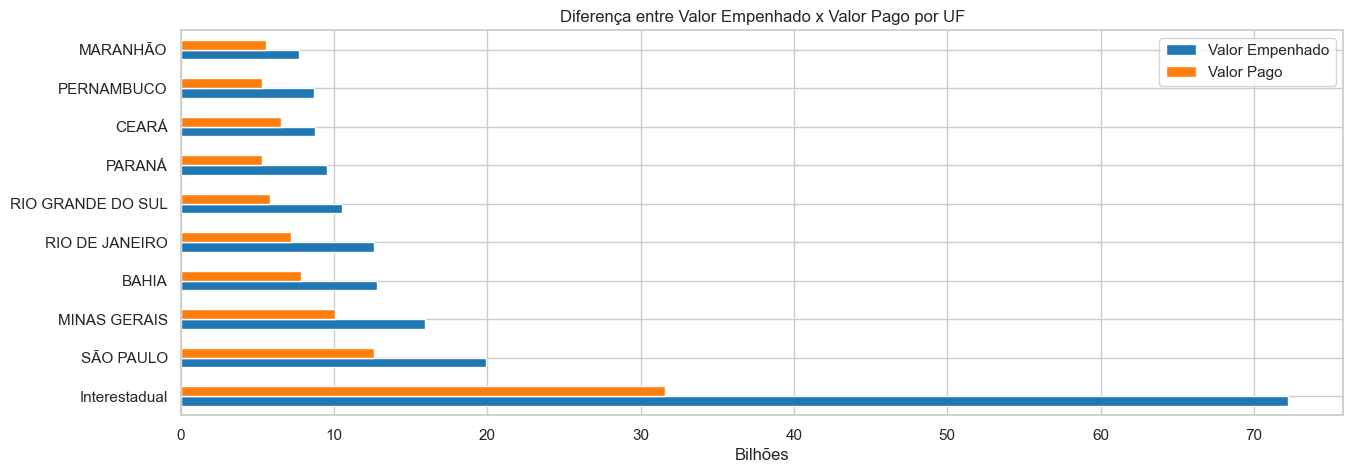

In [48]:
# ordenando e filtrando somente os 10 maiores
gap_empenhado_e_pago = gap_empenhado_e_pago.sort_values(by="Valor Empenhado", ascending=False).head(10)

gap_empenhado_e_pago.plot(kind='barh', figsize=(15, 5), color=['#1f77b4', '#ff7f0e'])
plt.title('Diferença entre Valor Empenhado x Valor Pago por UF')
plt.xlabel('Bilhões')
plt.ylabel('')
plt.show()
plt.close()

In [ ]:
# criando a coluna eficiencia, que mostra a porcentagem de valor empenhado que foi pago
emendas.loc[:, "Eficiência"] = emendas["Valor Pago"] / emendas["Valor Empenhado"] * 100

estados_eficientes = emendas.loc[emendas["UF"] != "Interestadual", "Eficiência"] # excluindo os estados "Interestadual"
estados_eficientes = estados_eficientes.groupby(emendas["UF"]).mean(numeric_only=True).sort_values(ascending=False) 

estados_eficientes = estados_eficientes.head(10) # coletando somente os 10 estados mais eficientes

UF
CEARÁ                 44.651222
MARANHÃO              41.591390
SÃO PAULO             40.800327
RIO DE JANEIRO        40.431199
AMAZONAS              39.734329
PARÁ                  37.481821
MATO GROSSO           36.751526
AMAPÁ                 35.932894
MATO GROSSO DO SUL    35.449005
ALAGOAS               35.249935
Name: Eficiência, dtype: float64

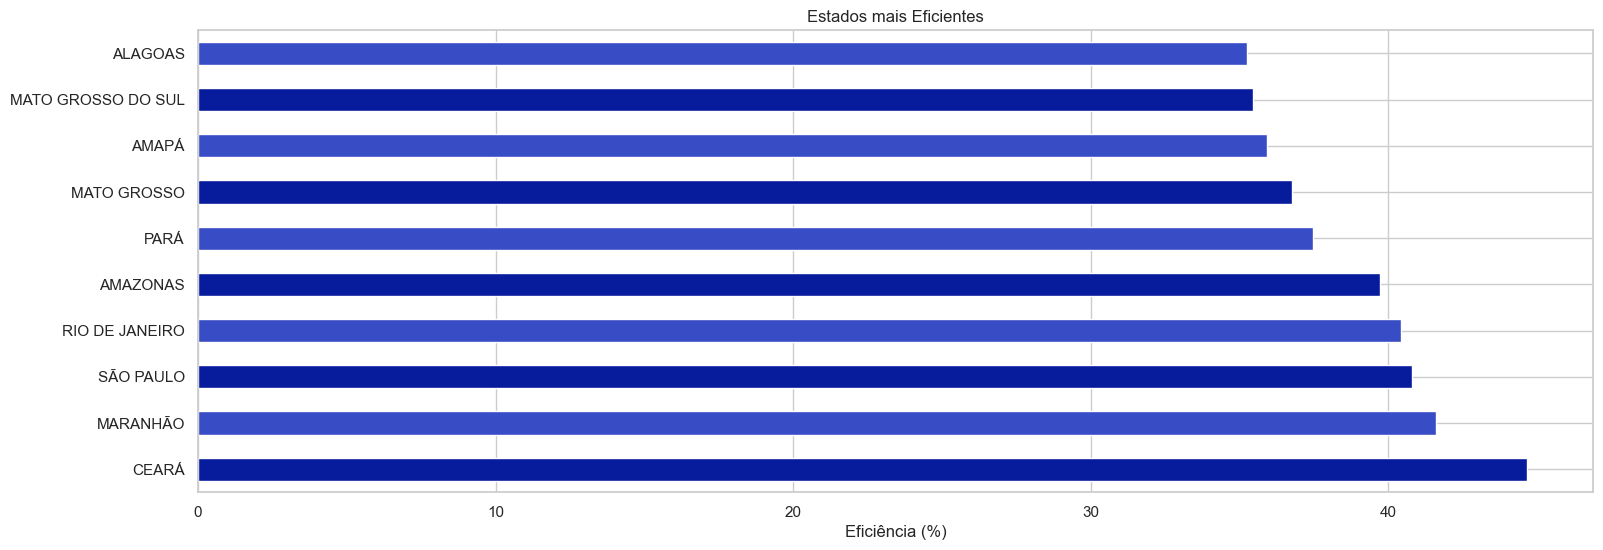

In [47]:
estados_eficientes.plot(kind='barh', figsize=(18, 6), color=["#061c9c","#374cc5"])
plt.title('Estados mais Eficientes')
plt.xlabel("Eficiência (%)")
plt.ylabel('')
plt.show()